# Ejercicio 1 : MLP a mano (NumPy) sobre Iris: 4×3×3 vs 4×3×3×3×3


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn import datasets

np.random.seed(42)

In [2]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")   # 0=>[1 0 0] 1=>[0 1 0] 2=>[0 0 1]

for idx in (0, 50, 100):
    print(X[idx], target[idx], Y[idx])

[5.1 3.5 1.4 0.2] 0 [1 0 0]
[7.  3.2 4.7 1.4] 1 [0 1 0]
[6.3 3.3 6.  2.5] 2 [0 0 1]


## Funciones comunes

In [3]:
def generate_weights(num_weights):
    # w[0] = sesgo (bias), w[1:] = pesos de las entradas
    return np.random.rand(num_weights) - 0.5

def net_input(input_vector, w):
    return w[0] + np.dot(w[1:], input_vector)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def propagate(x, w):
    return sigmoid(net_input(x, w))

def accuracy(forward_fn):
    ok = sum(np.argmax(forward_fn(X[i])) == target[i] for i in range(len(X)))
    return ok / len(X)

## Corrida A — red original 4×3×3
Una capa oculta (`layer1`) y la capa de salida (`layer2`).

época   0  error = 0.6683
época  50  error = 0.3458
época 100  error = 0.2460
época 150  error = 0.1523
época 200  error = 0.1114
época 250  error = 0.0908
época 300  error = 0.0788
época 350  error = 0.0711
época 400  error = 0.0659
época 450  error = 0.0623

A (4x3x3)  error final = 0.0596 | exactitud = 96.67% | tiempo = 9.1s


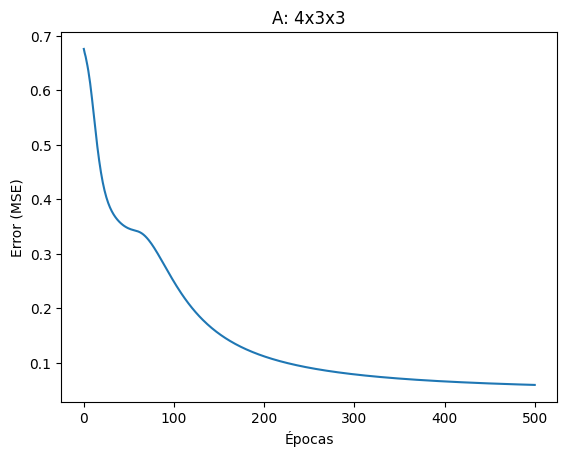

In [4]:
# ---------- Corrida A: 4 x 3 x 3 ----------
input_size = 4
n1, n2 = 3, 3
layer1, layer2 = [], []

def init_weights_A():
    layer1.clear(); layer2.clear()
    for _ in range(n1): layer1.append(generate_weights(input_size + 1))
    for _ in range(n2): layer2.append(generate_weights(n1 + 1))

def forward_A(x):
    o1 = np.array([propagate(x, w) for w in layer1])
    o2 = np.array([propagate(o1, w) for w in layer2])
    return o2

def calculate_error_A():
    total = 0
    for idx in range(len(X)):
        err = Y[idx] - forward_A(X[idx])
        total += np.sum(err ** 2)
    return total / len(X)

alpha, epochs = 0.03, 500

init_weights_A()
E_A = [calculate_error_A()]
t0 = time.time()
for e in range(epochs):
    for d in range(len(X)):
        # propagación
        o1 = np.array([propagate(X[d], w) for w in layer1])
        o2 = np.array([propagate(o1, w) for w in layer2])
        # retropropagación (de la salida hacia la entrada)
        delta2 = o2 * (1 - o2) * (Y[d] - o2)
        delta1 = np.zeros(n1)
        for i in range(n1):
            s = sum(layer2[j][i+1] * delta2[j] for j in range(n2))
            delta1[i] = o1[i] * (1 - o1[i]) * s
        # actualización de pesos
        for i in range(n2):
            layer2[i][0] += alpha * delta2[i]
            layer2[i][1:] += alpha * delta2[i] * o1
        for i in range(n1):
            layer1[i][0] += alpha * delta1[i]
            layer1[i][1:] += alpha * delta1[i] * X[d]
    E_A.append(calculate_error_A())
    if e % 50 == 0:
        print(f"época {e:3d}  error = {E_A[-1]:.4f}")
time_A = time.time() - t0

print(f"\nA (4x3x3)  error final = {E_A[-1]:.4f} | exactitud = {accuracy(forward_A):.2%} | tiempo = {time_A:.1f}s")
plt.plot(E_A); plt.xlabel("Épocas"); plt.ylabel("Error (MSE)"); plt.title("A: 4x3x3"); plt.show()

## Corrida B — red profunda 4×3×3×3×3
Se agregan **dos capas ocultas** (`layer2`, `layer3`); la salida pasa a ser `layer4` y sigue teniendo 3 neuronas.
Se actualizan **tamaños, inicialización, forward de `calculate_error`, propagación, retropropagación y actualización de pesos**.

época   0  error = 0.7084
época  50  error = 0.6706
época 100  error = 0.6704
época 150  error = 0.6702
época 200  error = 0.6700
época 250  error = 0.6698
época 300  error = 0.6694
época 350  error = 0.6682
época 400  error = 0.6618
época 450  error = 0.5348

B (4x3x3x3x3)  error final = 0.4064 | exactitud = 70.67% | tiempo = 17.0s
Norma de los delta en la 1ª iteración (capa1..capa4): ['2.9e-04', '3.9e-03', '2.7e-02', '2.4e-01']


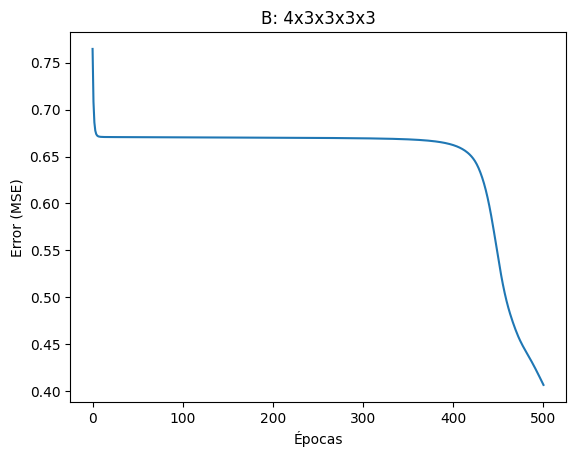

In [5]:
# ---------- Corrida B: 4 x 3 x 3 x 3 x 3 ----------
np.random.seed(42)
input_size = 4
m1 = m2 = m3 = m4 = 3
L1, L2, L3, L4 = [], [], [], []

def init_weights_B():
    for L in (L1, L2, L3, L4): L.clear()
    for _ in range(m1): L1.append(generate_weights(input_size + 1))
    for _ in range(m2): L2.append(generate_weights(m1 + 1))
    for _ in range(m3): L3.append(generate_weights(m2 + 1))
    for _ in range(m4): L4.append(generate_weights(m3 + 1))

def forward_B(x):
    o1 = np.array([propagate(x,  w) for w in L1])
    o2 = np.array([propagate(o1, w) for w in L2])
    o3 = np.array([propagate(o2, w) for w in L3])
    o4 = np.array([propagate(o3, w) for w in L4])
    return o4

def calculate_error_B():
    total = 0
    for idx in range(len(X)):
        err = Y[idx] - forward_B(X[idx])
        total += np.sum(err ** 2)
    return total / len(X)

init_weights_B()
E_B = [calculate_error_B()]
grad_norms = None
t0 = time.time()
for e in range(epochs):
    for d in range(len(X)):
        # propagación
        o1 = np.array([propagate(X[d], w) for w in L1])
        o2 = np.array([propagate(o1, w) for w in L2])
        o3 = np.array([propagate(o2, w) for w in L3])
        o4 = np.array([propagate(o3, w) for w in L4])
        # retropropagación: cada delta usa los pesos y delta de la capa SIGUIENTE
        delta4 = o4 * (1 - o4) * (Y[d] - o4)
        delta3 = np.array([o3[i] * (1 - o3[i]) * sum(L4[j][i+1] * delta4[j] for j in range(m4)) for i in range(m3)])
        delta2 = np.array([o2[i] * (1 - o2[i]) * sum(L3[j][i+1] * delta3[j] for j in range(m3)) for i in range(m2)])
        delta1 = np.array([o1[i] * (1 - o1[i]) * sum(L2[j][i+1] * delta2[j] for j in range(m2)) for i in range(m1)])
        if e == 0 and d == 0:
            grad_norms = [np.linalg.norm(x) for x in (delta1, delta2, delta3, delta4)]
        # actualización de pesos (los deltas ya se calcularon con los pesos viejos)
        for i in range(m4): L4[i][0] += alpha * delta4[i]; L4[i][1:] += alpha * delta4[i] * o3
        for i in range(m3): L3[i][0] += alpha * delta3[i]; L3[i][1:] += alpha * delta3[i] * o2
        for i in range(m2): L2[i][0] += alpha * delta2[i]; L2[i][1:] += alpha * delta2[i] * o1
        for i in range(m1): L1[i][0] += alpha * delta1[i]; L1[i][1:] += alpha * delta1[i] * X[d]
    E_B.append(calculate_error_B())
    if e % 50 == 0:
        print(f"época {e:3d}  error = {E_B[-1]:.4f}")
time_B = time.time() - t0

print(f"\nB (4x3x3x3x3)  error final = {E_B[-1]:.4f} | exactitud = {accuracy(forward_B):.2%} | tiempo = {time_B:.1f}s")
print("Norma de los delta en la 1ª iteración (capa1..capa4):", ["%.1e" % g for g in grad_norms])
plt.plot(E_B); plt.xlabel("Épocas"); plt.ylabel("Error (MSE)"); plt.title("B: 4x3x3x3x3"); plt.show()

## Comparación A vs B

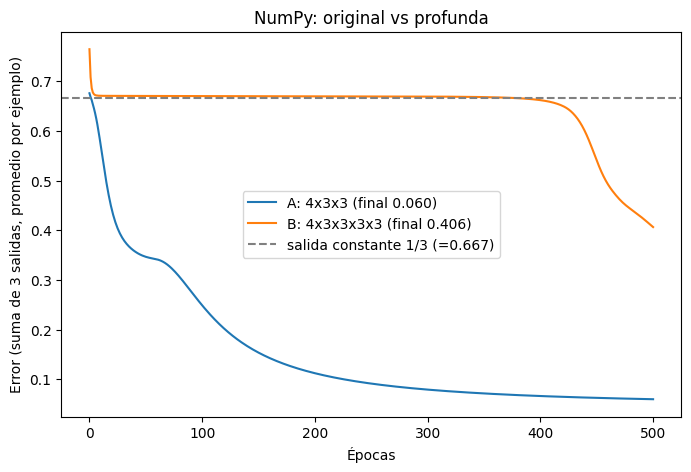

                 error final  exactitud  tiempo (s)
A 4x3x3               0.0596     96.67%         9.1
B 4x3x3x3x3           0.4064     70.67%        17.0

OJO: este error SUMA las 3 salidas; el MSE de Keras las PROMEDIA -> error_numpy / 3 = MSE de Keras.


In [6]:
plt.figure(figsize=(8,5))
plt.plot(E_A, label=f"A: 4x3x3 (final {E_A[-1]:.3f})")
plt.plot(E_B, label=f"B: 4x3x3x3x3 (final {E_B[-1]:.3f})")
plt.axhline(2/3, color="gray", ls="--", label="salida constante 1/3 (=0.667)")
plt.xlabel("Épocas"); plt.ylabel("Error (suma de 3 salidas, promedio por ejemplo)")
plt.legend(); plt.title("NumPy: original vs profunda"); plt.show()

print(f"{'':16}{'error final':>12}{'exactitud':>11}{'tiempo (s)':>12}")
print(f"{'A 4x3x3':16}{E_A[-1]:12.4f}{accuracy(forward_A):11.2%}{time_A:12.1f}")
print(f"{'B 4x3x3x3x3':16}{E_B[-1]:12.4f}{accuracy(forward_B):11.2%}{time_B:12.1f}")
print("\nOJO: este error SUMA las 3 salidas; el MSE de Keras las PROMEDIA -> error_numpy / 3 = MSE de Keras.")

## Notas para el reporte
- El resultado depende de la semilla: con otra inicialización la red profunda puede aprender. Si quieres un dato robusto, repite B con varias semillas (`np.random.seed(0..4)`).
- Un error ≈ 0.667 equivale a emitir ≈ 1/3 en las 3 salidas (la red no discrimina clases).
- Las normas de los δ por capa (celda B) muestran el gradiente que se desvanece: cada capa hacia atrás multiplica por σ'(z) ≤ 0.25.